In [4]:
%%html
<h1> House Price Prediction - Data Cleaning & EDA</h1>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [5]:
# ---- 1. Load the data ----
df = pd.read_excel("house_price_dataset.xlsx", sheet_name="House_Price_Data")
df.head()

,PropertyID,City,LocalityType,PropertyType,BHK,Bathrooms,AreaSqft,FloorNo,TotalFloors,AgeOfProperty,Furnishing,Parking,HasLift,NearbySchools,DistanceToCityCenter_km,Price
0,PROP2266,Ahmedabad,Suburban,Apartment,2,2,1391.0,5,13,2,Semi-Furnished,1,Yes,0.0,4.5,7550000
1,PROP2567,Kolkata,Urban,Independent House,1,1,1657.0,12,21,11,Furnished,1,Yes,7.0,12.0,11354000
2,PROP3057,Pune,Urban,Villa,3,2,1362.0,6,9,8,Furnished,1,Yes,8.0,11.7,13362000
3,PROP2487,Ahmedabad,Urban,Villa,2,2,2047.0,19,22,33,Unfurnished,2,Yes,1.0,10.3,9972000
4,PROP2725,Hyderabad,Urban,Independent House,2,2,2210.0,10,14,3,Furnished,2,Yes,5.0,0.5,19375000


In [6]:
print("Shape:", df.shape)
df.info()

Shape: (1510, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1510 entries, 0 to 1509
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PropertyID               1510 non-null   object 
 1   City                     1510 non-null   object 
 2   LocalityType             1510 non-null   object 
 3   PropertyType             1510 non-null   object 
 4   BHK                      1510 non-null   int64  
 5   Bathrooms                1510 non-null   int64  
 6   AreaSqft                 1488 non-null   float64
 7   FloorNo                  1510 non-null   int64  
 8   TotalFloors              1510 non-null   int64  
 9   AgeOfProperty            1510 non-null   int64  
 10  Furnishing               1495 non-null   object 
 11  Parking                  1510 non-null   int64  
 12  HasLift                  1488 non-null   object 
 13  NearbySchools            1495 non-null   float64
 14  Distan

In [7]:
df.describe(include="all")

,PropertyID,City,LocalityType,PropertyType,BHK,Bathrooms,AreaSqft,FloorNo,TotalFloors,AgeOfProperty,Furnishing,Parking,HasLift,NearbySchools,DistanceToCityCenter_km,Price
count,1510,1510,1510,1510,1510.000000,1510.000000,1488.000000,1510.000000,1510.000000,1510.000000,1495,1510.000000,1488,1495.000000,1510.000000,1.510000e+03
unique,1500,16,6,4,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,2,NaN,NaN,NaN
top,PROP2755,Mumbai,Urban,Villa,NaN,NaN,NaN,NaN,NaN,NaN,Unfurnished,NaN,Yes,NaN,NaN,NaN
freq,2,200,732,411,NaN,NaN,NaN,NaN,NaN,NaN,506,NaN,982,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2.689404,1.936424,1433.617608,11.896689,16.803974,17.132450,NaN,1.291391,NaN,4.573244,14.703841,1.053005e+07
std,NaN,NaN,NaN,NaN,1.066177,0.742489,575.353709,7.144902,7.624729,11.435343,NaN,0.830095,NaN,2.883008,8.587768,6.135928e+06
min,NaN,NaN,NaN,NaN,1.000000,1.000000,400.000000,0.000000,1.000000,-3.000000,NaN,0.000000,NaN,0.000000,0.500000,1.369000e+06
25%,NaN,NaN,NaN,NaN,2.000000,1.000000,1048.000000,6.000000,10.000000,9.000000,NaN,1.000000,NaN,2.000000,7.500000,6.215500e+06
50%,NaN,NaN,NaN,NaN,3.000000,2.000000,1415.000000,12.000000,17.000000,17.000000,NaN,1.000000,NaN,5.000000,14.600000,9.267000e+06
75%,NaN,NaN,NaN,NaN,3.000000,2.000000,1813.000000,18.000000,23.000000,25.000000,NaN,2.000000,NaN,7.000000,22.000000,1.321750e+07


In [8]:
## 3. Basic Data Cleaning

# %%
# Missing values check
df.isna().sum()

PropertyID                  0
City                        0
LocalityType                0
PropertyType                0
BHK                         0
Bathrooms                   0
AreaSqft                   22
FloorNo                     0
TotalFloors                 0
AgeOfProperty               0
Furnishing                 15
Parking                     0
HasLift                    22
NearbySchools              15
DistanceToCityCenter_km     0
Price                       0
dtype: int64

In [10]:
# Duplicates check
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Duplicate rows: 0
Shape after removing duplicates: (1500, 16)


In [11]:
# Fix inconsistent text formatting (case + whitespace)
for col in ["City", "LocalityType", "PropertyType", "Furnishing", "HasLift"]:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col] = df[col].replace("Nan", np.nan)

df[["City", "LocalityType", "Furnishing", "HasLift"]].drop_duplicates()    

,City,LocalityType,Furnishing,HasLift
0,Ahmedabad,Suburban,Semi-Furnished,Yes
1,Kolkata,Urban,Furnished,Yes
2,Pune,Urban,Furnished,Yes
3,Ahmedabad,Urban,Unfurnished,Yes
4,Hyderabad,Urban,Furnished,Yes
...,...,...,...,...
1333,Hyderabad,Suburban,NaN,No
1353,Kolkata,Suburban,NaN,No
1429,Kolkata,Suburban,Furnished,NaN
1462,Pune,Rural,Furnished,No


In [12]:
# Handle missing values
# AreaSqft -> fill with median (robust to outliers)
df["AreaSqft"] = df["AreaSqft"].fillna(df["AreaSqft"].median())

In [13]:
# Furnishing / HasLift -> fill with mode (most common value)
df["Furnishing"] = df["Furnishing"].fillna(df["Furnishing"].mode()[0])
df["HasLift"] = df["HasLift"].fillna(df["HasLift"].mode()[0])

In [14]:
# NearbySchools -> fill with median
df["NearbySchools"] = df["NearbySchools"].fillna(df["NearbySchools"].median())

In [15]:
df.isna().sum()

PropertyID                 0
City                       0
LocalityType               0
PropertyType               0
BHK                        0
Bathrooms                  0
AreaSqft                   0
FloorNo                    0
TotalFloors                0
AgeOfProperty              0
Furnishing                 0
Parking                    0
HasLift                    0
NearbySchools              0
DistanceToCityCenter_km    0
Price                      0
dtype: int64

In [16]:
# Fix invalid / outlier AgeOfProperty (negative or unrealistically high)
df = df[(df["AgeOfProperty"] >= 0) & (df["AgeOfProperty"] <= 60)]

In [17]:
# Cap extreme AreaSqft outliers using IQR method
Q1 = df["AreaSqft"].quantile(0.25)
Q3 = df["AreaSqft"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df = df[(df["AreaSqft"] >= max(lower_limit, 200)) & (df["AreaSqft"] <= upper_limit)]

print("Shape after cleaning:", df.shape)

Shape after cleaning: (1491, 16)


In [19]:
# Sanity check: Price should be positive and reasonable
df = df[df["Price"] > 0]
df.describe()


,BHK,Bathrooms,AreaSqft,FloorNo,TotalFloors,AgeOfProperty,Parking,NearbySchools,DistanceToCityCenter_km,Price
count,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1.491000e+03
mean,2.687458,1.936955,1418.830986,11.902750,16.808853,16.955734,1.294433,4.587525,14.688531,1.051760e+07
std,1.059427,0.741879,526.506425,7.141565,7.614122,9.840373,0.830518,2.865594,8.582166,6.138969e+06
min,1.000000,1.000000,400.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.500000,1.369000e+06
25%,2.000000,1.000000,1056.000000,6.000000,10.000000,9.000000,1.000000,2.000000,7.400000,6.216000e+06
50%,3.000000,2.000000,1414.000000,12.000000,17.000000,17.000000,1.000000,5.000000,14.500000,9.234000e+06
75%,3.000000,2.000000,1796.000000,18.000000,23.000000,25.000000,2.000000,7.000000,21.900000,1.319850e+07
max,5.000000,4.000000,2893.000000,24.000000,33.000000,34.000000,3.000000,9.000000,30.000000,5.122000e+07


In [20]:
%%html
<h1>Univariate Analysis </h1>

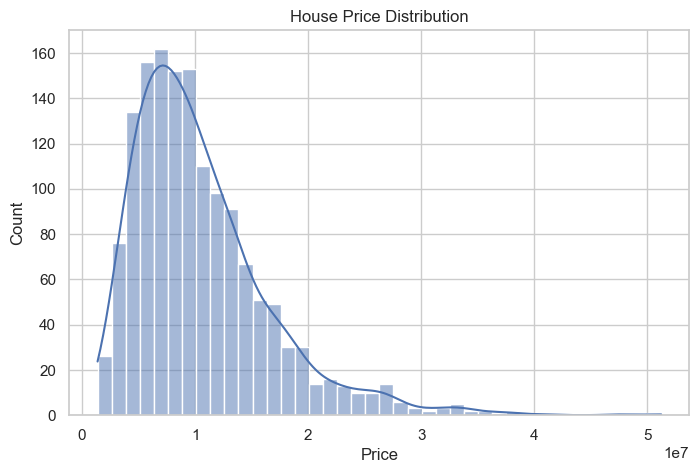

In [21]:
sns.histplot(df["Price"], bins=40, kde=True)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.show()


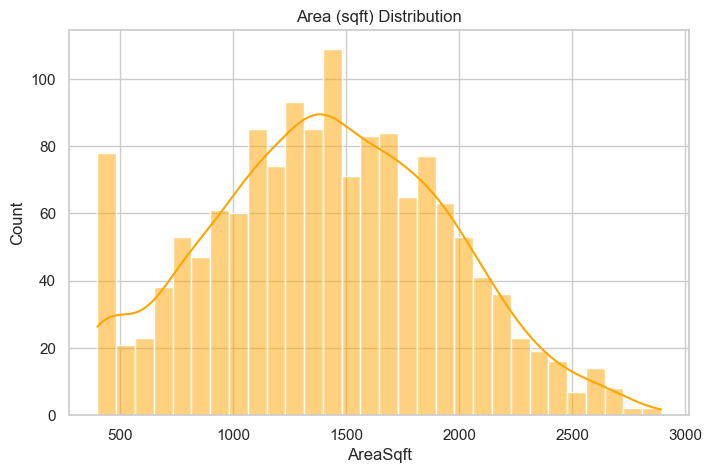

In [22]:
# AreaSqft distribution
sns.histplot(df["AreaSqft"], bins=30, kde=True, color="orange")
plt.title("Area (sqft) Distribution")
plt.show()

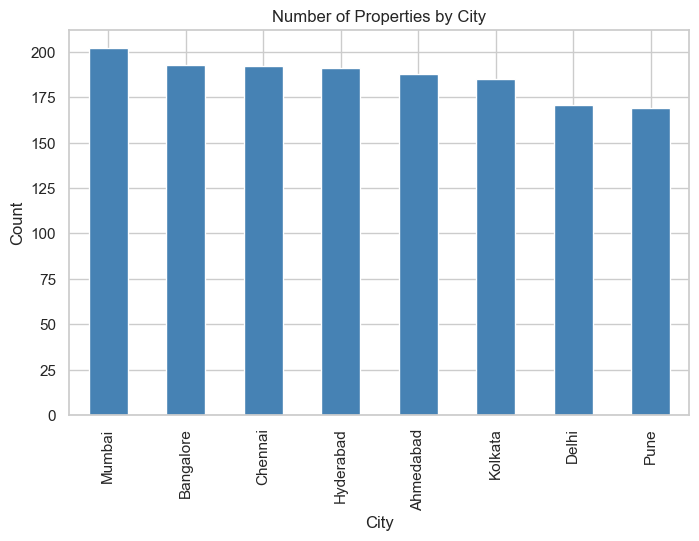

In [23]:
# Property count by City
df["City"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Number of Properties by City")
plt.ylabel("Count")
plt.show()

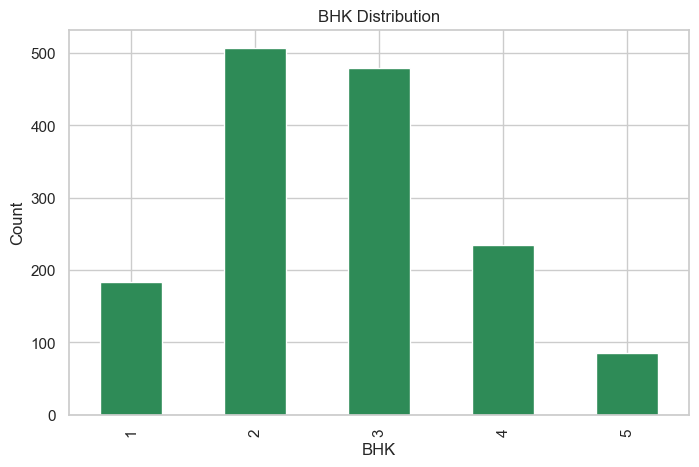

In [24]:
# BHK distribution
df["BHK"].value_counts().sort_index().plot(kind="bar", color="seagreen")
plt.title("BHK Distribution")
plt.xlabel("BHK")
plt.ylabel("Count")
plt.show()

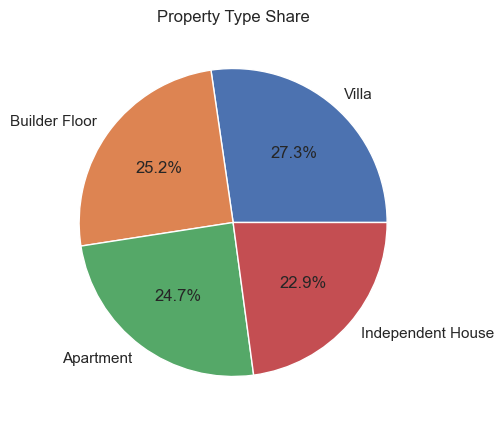

In [25]:
# Property Type share
df["PropertyType"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Property Type Share")
plt.ylabel("")
plt.show()

In [26]:
%%html
<h2> Bivariate Analysis (relationship with Price)</h2>

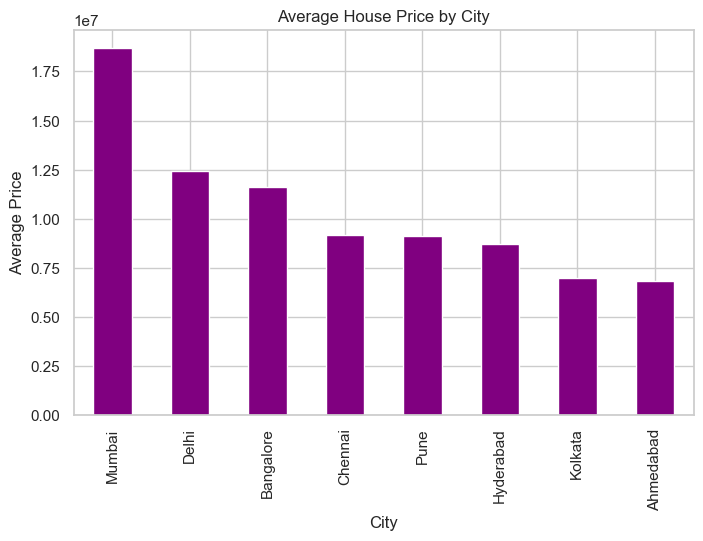

In [27]:
# Average Price by City
avg_price_city = df.groupby("City")["Price"].mean().sort_values(ascending=False)
avg_price_city.plot(kind="bar", color="purple")
plt.title("Average House Price by City")
plt.ylabel("Average Price")
plt.show()

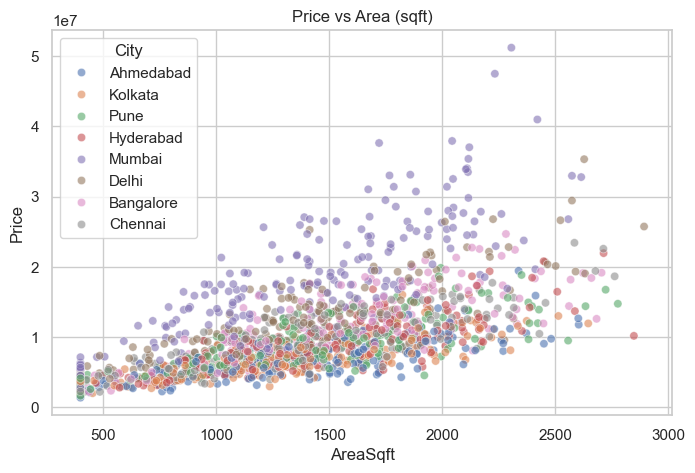

In [29]:
# Price vs AreaSqft (scatter)
sns.scatterplot(data=df, x="AreaSqft", y="Price", hue="City", alpha=0.6)
plt.title("Price vs Area (sqft)")
plt.show()

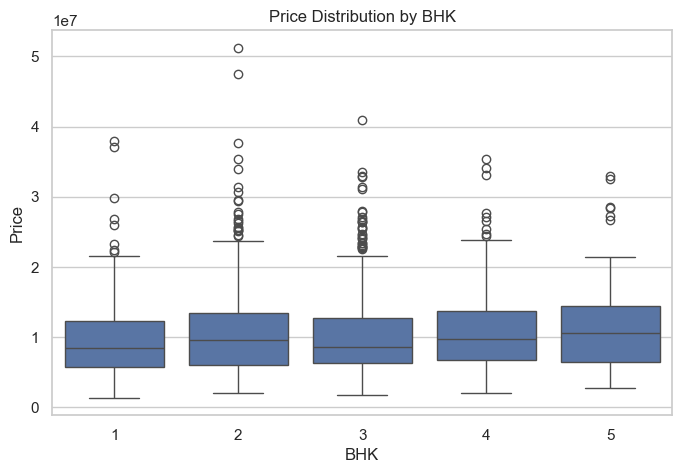

In [31]:
# Price by BHK (boxplot)
sns.boxplot(data=df, x="BHK", y="Price")
plt.title("Price Distribution by BHK")
plt.show()

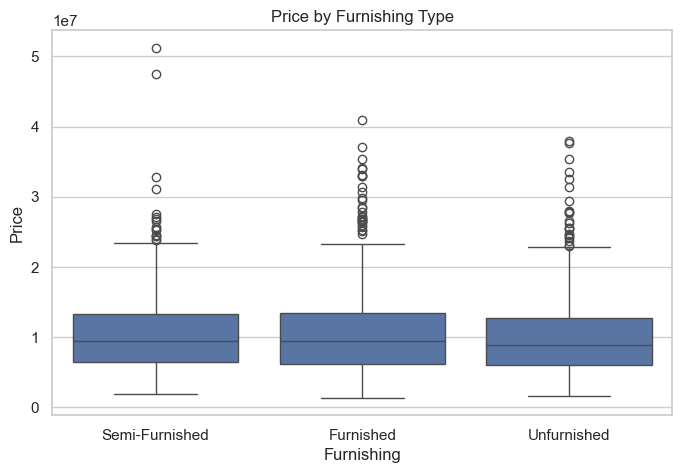

In [32]:
# Price by Furnishing type
sns.boxplot(data=df, x="Furnishing", y="Price")
plt.title("Price by Furnishing Type")
plt.show()

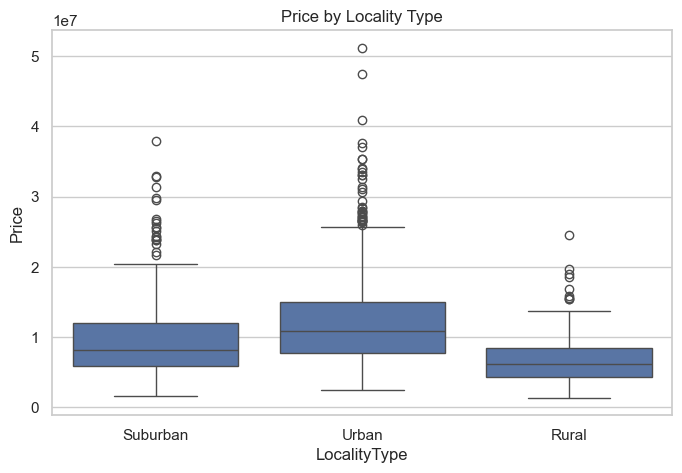

In [34]:
# Price by Locality Type
sns.boxplot(data=df, x="LocalityType", y="Price")
plt.title("Price by Locality Type")
plt.show()

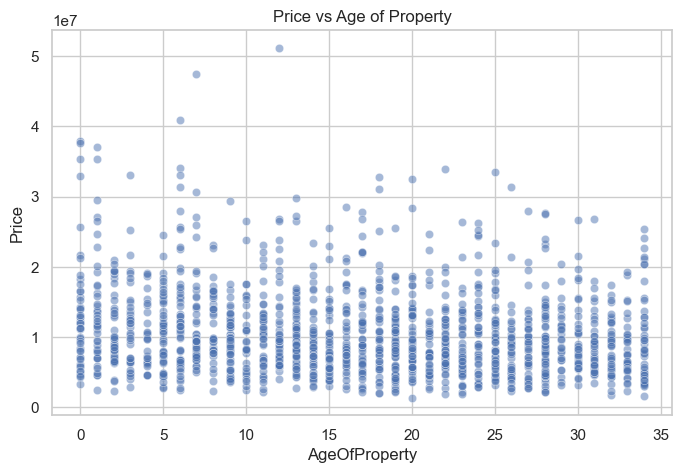

In [35]:
# Price vs Age of Property
sns.scatterplot(data=df, x="AgeOfProperty", y="Price", alpha=0.5)
plt.title("Price vs Age of Property")
plt.show()

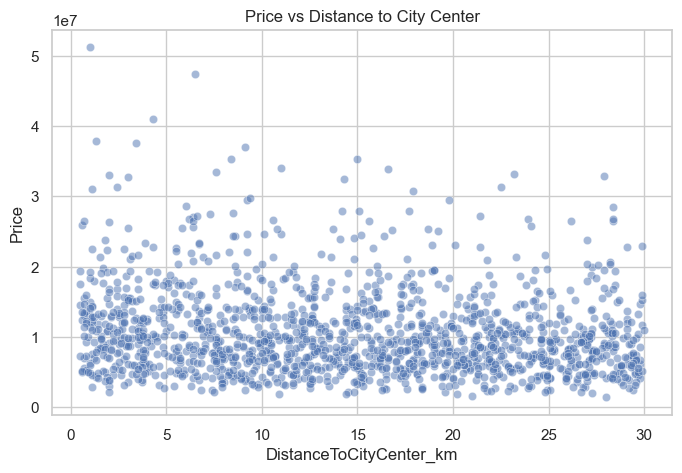

In [36]:
# Price vs Distance to City Center
sns.scatterplot(data=df, x="DistanceToCityCenter_km", y="Price", alpha=0.5)
plt.title("Price vs Distance to City Center")
plt.show()


In [37]:
%%html
<h2>Correlation Analysis </h2>

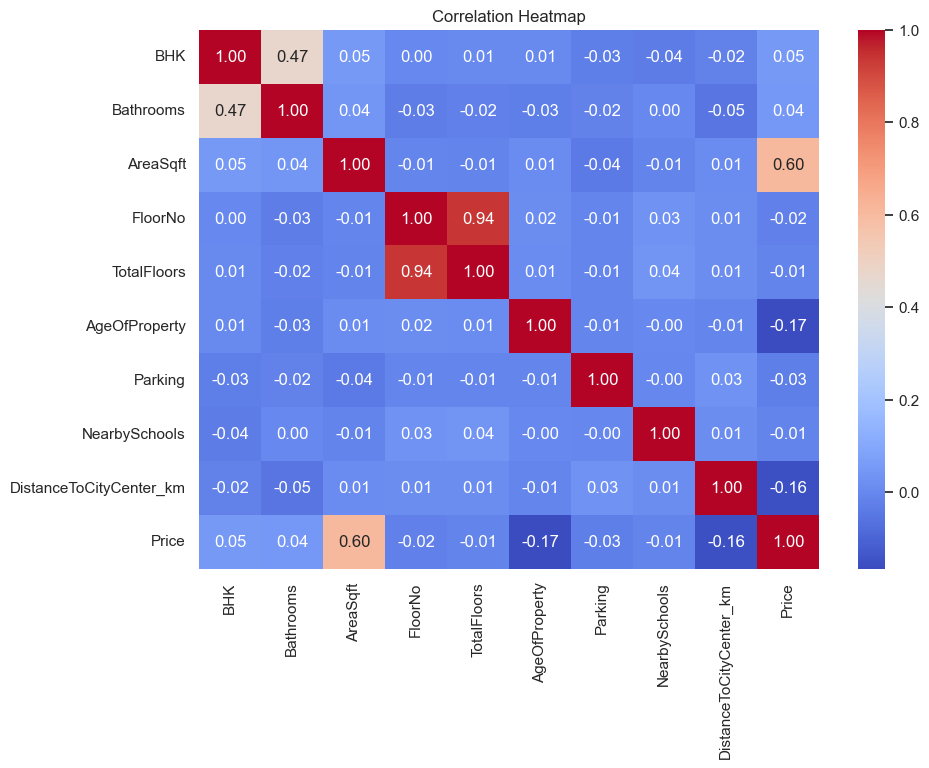

In [38]:

numeric_cols = ["BHK", "Bathrooms", "AreaSqft", "FloorNo", "TotalFloors",
                 "AgeOfProperty", "Parking", "NearbySchools",
                 "DistanceToCityCenter_km", "Price"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [39]:
corr["Price"].sort_values(ascending=False)

Price                      1.000000
AreaSqft                   0.604918
BHK                        0.052369
Bathrooms                  0.044998
NearbySchools             -0.011413
TotalFloors               -0.012492
FloorNo                   -0.024086
Parking                   -0.025733
DistanceToCityCenter_km   -0.156779
AgeOfProperty             -0.165956
Name: Price, dtype: float64

In [40]:
%%html
<h1> Model building </h1>

In [42]:
# Feature Engineering ----
model_df = df.drop(columns=["PropertyID"])

X = model_df.drop(columns=["Price"])
y = model_df["Price"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['City', 'LocalityType', 'PropertyType', 'Furnishing', 'HasLift']
Numerical columns: ['BHK', 'Bathrooms', 'AreaSqft', 'FloorNo', 'TotalFloors', 'AgeOfProperty', 'Parking', 'NearbySchools', 'DistanceToCityCenter_km']


In [43]:
# One-Hot Encode categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [46]:
# . Train-Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)


In [45]:
# Scale numerical features (helps Linear/Ridge Regression)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])


In [47]:
# ---- 4. Model Training ----
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R2   : {r2:.4f}\n")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

In [48]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
results.append(evaluate_model("Linear Regression", y_test, pred_lr))

--- Linear Regression ---
MAE  : 1,290,251.27
RMSE : 1,775,354.03
R2   : 0.9026



In [49]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
pred_ridge = ridge.predict(X_test_scaled)
results.append(evaluate_model("Ridge Regression", y_test, pred_ridge))

--- Ridge Regression ---
MAE  : 1,285,261.71
RMSE : 1,768,922.24
R2   : 0.9033



In [50]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results.append(evaluate_model("Random Forest", y_test, pred_rf))


--- Random Forest ---
MAE  : 1,441,826.05
RMSE : 1,988,874.83
R2   : 0.8777



In [51]:
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
results.append(evaluate_model("Gradient Boosting", y_test, pred_gb))

--- Gradient Boosting ---
MAE  : 1,016,395.27
RMSE : 1,471,821.67
R2   : 0.9330



               Model           MAE          RMSE        R2
3  Gradient Boosting  1.016395e+06  1.471822e+06  0.933046
1   Ridge Regression  1.285262e+06  1.768922e+06  0.903288
0  Linear Regression  1.290251e+06  1.775354e+06  0.902583
2      Random Forest  1.441826e+06  1.988875e+06  0.877742


C:\Users\DELL\AppData\Local\Temp\ipykernel_20532\1092687053.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2", palette="viridis")


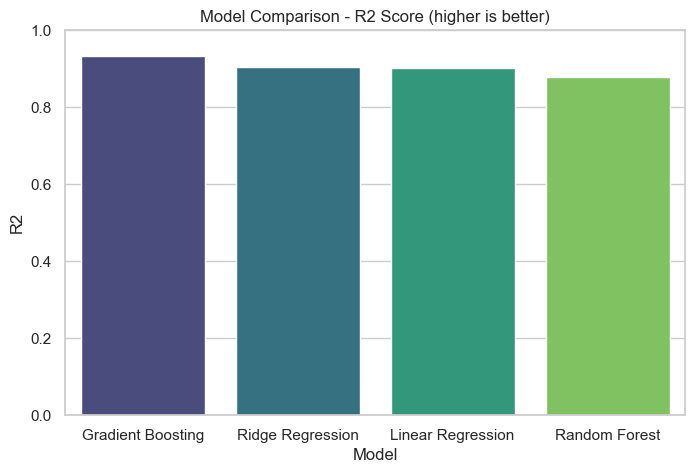

C:\Users\DELL\AppData\Local\Temp\ipykernel_20532\1092687053.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", palette="magma")


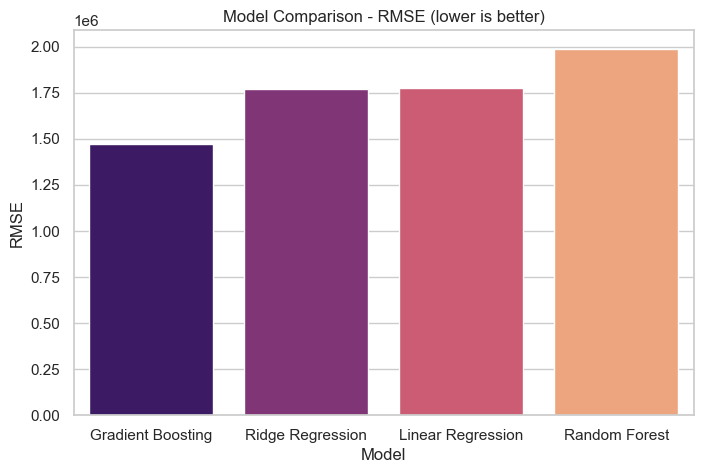

In [53]:
#  Compare All Models ----
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print(results_df)
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="R2", palette="viridis")
plt.title("Model Comparison - R2 Score (higher is better)")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="RMSE", palette="magma")
plt.title("Model Comparison - RMSE (lower is better)")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_20532\883034064.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="crest")


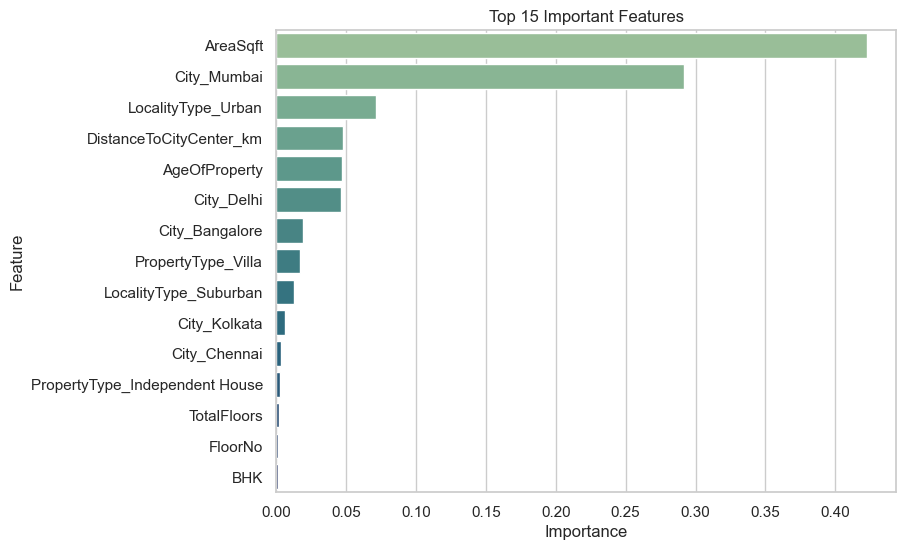

In [54]:
#  Feature Importance (Best Tree-Based Model) ----
best_tree_model = rf if results_df.iloc[0]["Model"] == "Random Forest" else gb

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", palette="crest")
plt.title("Top 15 Important Features")
plt.show()

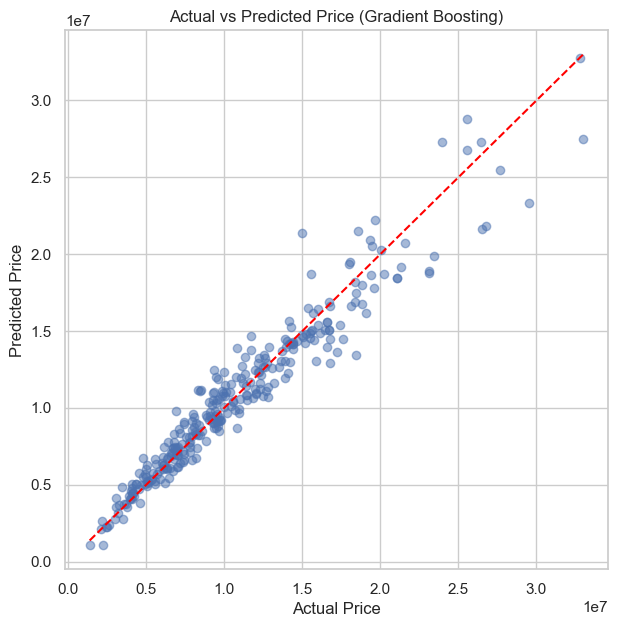

In [55]:
# ---- 7. Actual vs Predicted (Best Model) ----
best_model_name = results_df.iloc[0]["Model"]
best_pred = {"Linear Regression": pred_lr, "Ridge Regression": pred_ridge,
             "Random Forest": pred_rf, "Gradient Boosting": pred_gb}[best_model_name]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price ({best_model_name})")
plt.show()

In [65]:
# ---- 8. Save the Best Model ----
import joblib
joblib.dump(best_tree_model if best_model_name in ["Random Forest", "Gradient Boosting"] else ridge,
            "house_price_best_model.pkl")
print(f"Best model ({best_model_name}) saved as house_price_best_model.pynb")

Best model (Gradient Boosting) saved as house_price_best_model.pynb


In [63]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

train_score = r2_score(y_train, lr.predict(X_train_scaled))
test_score = r2_score(y_test, lr.predict(X_test_scaled))

print(f"Train R2: {train_score:.4f}")
print(f"Test R2: {test_score:.4f}")

Train R2: 0.8790
Test R2: 0.9026


In [58]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

train_score_lasso = r2_score(y_train, lasso.predict(X_train_scaled))
test_score_lasso = r2_score(y_test, lasso.predict(X_test_scaled))

print(f"Lasso Train R2: {train_score_lasso:.4f}")
print(f"Lasso Test R2: {test_score_lasso:.4f}")

Lasso Train R2: 0.8790
Lasso Test R2: 0.9026


In [59]:
# cross validation check
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
print("CV Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

CV Scores: [0.88888398 0.87815693 0.86193759 0.88428296 0.85511488]
Mean CV R2: 0.8736752686144902
Std Dev: 0.013009029455928476


In [60]:
%%html
<h2> Check the model on new data</h2>

In [67]:

import joblib

# ---- 1. Model aur training column list dono save karo (model training ke time) ----
# Yeh line apne model_building script mein X_train_scaled ke baad add kar dena:
joblib.dump(list(X_train.columns), "model_columns.pkl")

['model_columns.pkl']

In [69]:
model = joblib.load("house_price_best_model.pkl")
model_columns = joblib.load("model_columns.pkl")   # training ke time ka exact column order


new_house = pd.DataFrame({
    "City": ["Mumbai"],
    "LocalityType": ["Urban"],
    "PropertyType": ["Apartment"],
    "BHK": [3],
    "Bathrooms": [2],
    "AreaSqft": [1500],
    "FloorNo": [4],
    "TotalFloors": [10],
    "AgeOfProperty": [5],
    "Furnishing": ["Furnished"],
    "Parking": [1],
    "HasLift": ["Yes"],
    "NearbySchools": [3],
    "DistanceToCityCenter_km": [5.0],
})


new_house_encoded = pd.get_dummies(new_house)


new_house_final = new_house_encoded.reindex(columns=model_columns, fill_value=0)


#  Prediction
predicted_price = model.predict(new_house_final)
print("Predicted Price:", predicted_price[0])

Predicted Price: 25013848.750374082
